<a href="https://colab.research.google.com/github/ToluwaniOladeji/Formative-2_Principle-Component-Analysis/blob/main/PCA_Formative_2%5BPeer_Pair_Team_13%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

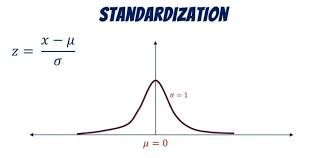


In [16]:
import numpy as np

filename = "conflict_data_cod.csv"
with open(filename, 'r', encoding='utf-8') as f:
    lines = f.readlines()

for i, line in enumerate(lines[:10]):
    print(f"Row {i}: {line[:100]}")

Row 0: data_id,iso,event_id_cnty,event_id_no_cnty,event_date,year,time_precision,event_type,sub_event_type,
Row 1: ,,#event+code,,#date+occurred,#date+year,,#event+type,,#group+name+first,#group+name+first+assoc,,#g
Row 2: 7173389,180,DRC18042,18042,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 3: 7173390,180,DRC18041,18041,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 4: 7173480,180,DRC18043,18043,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 5: 7173575,180,DRC18040,18040,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 6: 7173384,180,DRC18032,18032,2020-07-31,2020,1,Battles,Armed clash,Unidentified Armed Group (Democrati
Row 7: 7173386,180,DRC18035,18035,2020-07-31,2020,1,Battles,Armed clash,Mayi Mayi Militia (Nyatura),,3,Mili
Row 8: 7173393,180,DRC18031,18031,2020-07-31,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 9: 7173669,180,DRC18036,

In [17]:
print(f"Lines before dropping row 1: {len(lines)}")

# Safety check: only delete row 1 if it really is the HXL tag row
# (some of its leading fields are empty, so we look for a '#' tag inside it)
assert '#' in lines[1].split(',')[2], "Row 1 is not an HXL tag row - check the file!"
del lines[1]          # drop row 1, keep row 0 (header)

print(f"Lines after dropping row 1:  {len(lines)}")
for i, line in enumerate(lines[:3]):
    print(f"Row {i}: {line[:100]}")

Lines before dropping row 1: 17419
Lines after dropping row 1:  17418
Row 0: data_id,iso,event_id_cnty,event_id_no_cnty,event_date,year,time_precision,event_type,sub_event_type,
Row 1: 7173389,180,DRC18042,18042,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ
Row 2: 7173390,180,DRC18041,18041,2020-08-01,2020,1,Protests,Peaceful protest,Protesters (Democratic Republ


In [18]:
def parse_csv_line(text):
    """Split one CSV record into fields, respecting "quoted, fields" and "" escapes."""
    fields, cur, in_quotes, i = [], [], False, 0
    while i < len(text):
        ch = text[i]
        if in_quotes:
            if ch == '"':
                if i + 1 < len(text) and text[i + 1] == '"':   # escaped quote
                    cur.append('"'); i += 1
                else:
                    in_quotes = False
            else:
                cur.append(ch)
        else:
            if ch == '"':
                in_quotes = True
            elif ch == ',':
                fields.append(''.join(cur)); cur = []
            else:
                cur.append(ch)
        i += 1
    fields.append(''.join(cur))
    return fields

# Re-join records whose quoted field contains a line break (odd number of quotes so far)
records, buffer = [], ''
for line in lines:
    buffer += line
    if buffer.count('"') % 2 == 0:
        records.append(buffer.rstrip('\r\n'))
        buffer = ''

header = [h.strip().lstrip('\ufeff') for h in parse_csv_line(records[0])]
rows = []
for rec in records[1:]:
    vals = parse_csv_line(rec)
    if len(vals) == len(header):          # skip any malformed record
        rows.append(dict(zip(header, vals)))

print(f"Data rows after dropping HXL tag row: {len(rows)}")
print(f"Raw columns ({len(header)}): {header}")

Data rows after dropping HXL tag row: 17417
Raw columns (31): ['data_id', 'iso', 'event_id_cnty', 'event_id_no_cnty', 'event_date', 'year', 'time_precision', 'event_type', 'sub_event_type', 'actor1', 'assoc_actor_1', 'inter1', 'actor2', 'assoc_actor_2', 'inter2', 'interaction', 'region', 'country', 'admin1', 'admin2', 'admin3', 'location', 'latitude', 'longitude', 'geo_precision', 'source', 'source_scale', 'notes', 'fatalities', 'timestamp', 'iso3']


In [19]:
candidate_cols = ['fatalities', 'latitude', 'longitude', 'year', 'geo_precision',
                   'event_type', 'actor2']

n = len(rows)
print(f"{'Column':<15}{'Missing':>10}{'% Missing':>12}")
for c in candidate_cols:
    miss = sum(1 for r in rows if r[c].strip() == '')
    print(f"{c:<15}{miss:>10}{100*miss/n:>11.2f}%")

Column            Missing   % Missing
fatalities              0       0.00%
latitude                0       0.00%
longitude               0       0.00%
year                    0       0.00%
geo_precision           0       0.00%
event_type              0       0.00%
actor2               2395      13.75%


In [20]:
counts = {}
for r in rows:
    if r['actor2'].strip() != '':
        counts[r['actor2']] = counts.get(r['actor2'], 0) + 1

most_common = sorted(counts.items(), key=lambda kv: -kv[1])   # stable sort, highest count first
top4 = [name for name, _ in most_common[:4]]
print("Top 4 actor2 categories kept as-is:")
for name, cnt in most_common[:4]:
    print(f"  {name}  (n={cnt})")

def bucket_actor2(v):
    if v.strip() == '':
        return 'Unknown'          # imputed category for missing values
    elif v in top4:
        return v
    else:
        return 'Other'

for r in rows:
    r['actor2_has'] = 1.0 if r['actor2'].strip() != '' else 0.0  # missing-value indicator
    r['actor2_bucket'] = bucket_actor2(r['actor2'])              # imputed + bucketed category

Top 4 actor2 categories kept as-is:
  Civilians (Democratic Republic of Congo)  (n=6182)
  Military Forces of the Democratic Republic of Congo (2001-2019)  (n=1183)
  Police Forces of the Democratic Republic of Congo (2001-2019)  (n=574)
  Military Forces of the Democratic Republic of Congo (2019-)  (n=494)


The reason why we did bucketing was because the actor2 column containes 433 unique values and 342 of them appear in less than 10 rows so if we encode everything it will affect our PCA so we decided to group the uncommon second actors so that we can keep the encoding to six actors.

In [21]:
feature_cols_numeric = ['fatalities', 'latitude', 'longitude', 'year',
                         'geo_precision', 'actor2_has']
# Non-numeric / categorical features -> one-hot encode.
# (Label-encoding would assign arbitrary integers like 0,1,2,3 to categories
# such as "Battles", "Riots", "Protests" that have no real order, which would
# falsely tell PCA that "Riots" sits numerically "between" two other event
# types. One-hot encoding avoids that by giving each category its own 0/1
# column instead.)
feature_cols_categorical = ['event_type', 'actor2_bucket']

category_values = {}
for c in feature_cols_categorical:
    category_values[c] = sorted(set(r[c] for r in rows))
    print(f"{c} categories ({len(category_values[c])}): {category_values[c]}")

X_list = []
for r in rows:
    vals = [float(r[c]) for c in feature_cols_numeric]
    for c in feature_cols_categorical:
        vals += [1.0 if r[c] == cat else 0.0 for cat in category_values[c]]
    X_list.append(vals)

X_raw = np.array(X_list, dtype=np.float64)
one_hot_names = [f"{c}={cat}" for c in feature_cols_categorical for cat in category_values[c]]
feature_names = feature_cols_numeric + one_hot_names
print(f"\nFinal feature matrix shape: {X_raw.shape}")
print(f"Feature names ({len(feature_names)}): {feature_names}")

event_type categories (6): ['Battles', 'Explosions/Remote violence', 'Protests', 'Riots', 'Strategic developments', 'Violence against civilians']
actor2_bucket categories (6): ['Civilians (Democratic Republic of Congo)', 'Military Forces of the Democratic Republic of Congo (2001-2019)', 'Military Forces of the Democratic Republic of Congo (2019-)', 'Other', 'Police Forces of the Democratic Republic of Congo (2001-2019)', 'Unknown']

Final feature matrix shape: (17417, 18)
Feature names (18): ['fatalities', 'latitude', 'longitude', 'year', 'geo_precision', 'actor2_has', 'event_type=Battles', 'event_type=Explosions/Remote violence', 'event_type=Protests', 'event_type=Riots', 'event_type=Strategic developments', 'event_type=Violence against civilians', 'actor2_bucket=Civilians (Democratic Republic of Congo)', 'actor2_bucket=Military Forces of the Democratic Republic of Congo (2001-2019)', 'actor2_bucket=Military Forces of the Democratic Republic of Congo (2019-)', 'actor2_bucket=Other', '

In [22]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
# standardized_data = None  # Do not use sklearn
# standardized_data[:5]  # Display the first few rows of standardized data

# Step 1: Standardize the data (numpy only)
mean = X_raw.mean(axis=0)
std = X_raw.std(axis=0)
standardized_data = (X_raw - mean) / std

print("standardized_data[:5]")
print(standardized_data[:5].round(4))
print("\nSanity check -> mean per feature (should be ~0):", standardized_data.mean(axis=0).round(6))
print("Sanity check -> std  per feature (should be ~1):", standardized_data.std(axis=0).round(6))

standardized_data[:5]
[[-0.1657  1.4577 -1.9866  1.0827 -0.6891 -2.5044 -0.8355 -0.1036  3.0707
  -0.2553 -0.3392 -0.6829 -0.7418 -0.2699 -0.1709 -0.7801 -0.1846  2.5044]
 [-0.1657  0.947   0.7201  1.0827 -0.6891 -2.5044 -0.8355 -0.1036  3.0707
  -0.2553 -0.3392 -0.6829 -0.7418 -0.2699 -0.1709 -0.7801 -0.1846  2.5044]
 [-0.1657 -0.4639  0.4274  1.0827 -0.6891 -2.5044 -0.8355 -0.1036  3.0707
  -0.2553 -0.3392 -0.6829 -0.7418 -0.2699 -0.1709 -0.7801 -0.1846  2.5044]
 [-0.1657 -0.2869  0.3629  1.0827 -0.6891 -2.5044 -0.8355 -0.1036  3.0707
  -0.2553 -0.3392 -0.6829 -0.7418 -0.2699 -0.1709 -0.7801 -0.1846  2.5044]
 [-0.1657  0.5147  0.4725  1.0827  1.1368  0.3993  1.1969 -0.1036 -0.3257
  -0.2553 -0.3392 -0.6829 -0.7418 -0.2699  5.853  -0.7801 -0.1846 -0.3993]]

Sanity check -> mean per feature (should be ~0): [-0.  0. -0.  0.  0. -0.  0. -0. -0.  0.  0.  0. -0.  0. -0.  0.  0.  0.]
Sanity check -> std  per feature (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [23]:
# # Step 3: Calculate the Covariance Matrix
# cov_matrix = None  # Calculate covariance matrix
# cov_matrix

n_samples = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)

print(f"cov_matrix shape: {cov_matrix.shape}\n")
print(cov_matrix.round(3))

cov_matrix shape: (18, 18)

[[ 1.     0.017 -0.013 -0.133  0.01   0.066  0.039  0.043 -0.054 -0.025
  -0.056  0.032  0.025 -0.001 -0.01   0.034 -0.022 -0.066]
 [ 0.017  1.     0.303  0.017  0.114  0.097  0.037 -0.    -0.129 -0.118
  -0.017  0.114  0.11  -0.019  0.049 -0.008 -0.105 -0.097]
 [-0.013  0.303  1.     0.119  0.163  0.154  0.129 -0.027 -0.232 -0.142
  -0.018  0.101  0.086  0.058  0.076  0.021 -0.143 -0.154]
 [-0.133  0.017  0.119  1.     0.127 -0.046 -0.204 -0.084  0.172  0.092
  -0.026  0.095  0.121  0.013  0.171 -0.241  0.065  0.046]
 [ 0.01   0.114  0.163  0.127  1.     0.11   0.018 -0.026 -0.194 -0.116
   0.058  0.131  0.129  0.038  0.019 -0.048 -0.074 -0.11 ]
 [ 0.066  0.097  0.154 -0.046  0.11   1.     0.334  0.032 -0.552 -0.065
  -0.383  0.273  0.296  0.108  0.068  0.311  0.074 -1.   ]
 [ 0.039  0.037  0.129 -0.204  0.018  0.334  1.    -0.087 -0.272 -0.213
  -0.283 -0.571 -0.62   0.262  0.148  0.682 -0.056 -0.334]
 [ 0.043 -0.    -0.027 -0.084 -0.026  0.032 -0.087  1. 

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

The two main reasons why we computed the covariance matrix. First, it shows how much each pair of standardized features moves together, telling us the ones that we don't need, features that are highly correlated carry the same information that PCA can safely compress. Second, because the covariance matrix is symmetric and positive semi-definite, it guarantees real-valued, orthogonal eigenvectors, those eigenvectors are exactly the directions (principal components) of maximum variance that PCA needs to project the data onto.

## Task 3: Optimize Implementation for Performance and Handle Large Datasets

We already computed the covariance matrix above using vectorized numpy. Here we demonstrate *why* that matters: we time a naive (pure-Python) implementation against it, confirm a couple of smaller numpy-level optimizations, and show a chunked/streaming approach for datasets too large to fit in memory. We then continue on to eigendecomposition (Step 4) using the same `cov_matrix` computed above.

In [33]:
import time

# --- (1) Normal way (pure-Python triple loop) vs vectorized covariance ---
def cov_normal(X):
    n_s, n_f = X.shape
    Xm = X - X.mean(axis=0)
    C = np.zeros((n_f, n_f))
    for i in range(n_f):
        for j in range(n_f):
            s = 0.0
            for k in range(n_s):
                s += Xm[k, i] * Xm[k, j]
            C[i, j] = s / (n_s - 1)
    return C

def cov_vectorized(X):
    Xm = X - X.mean(axis=0)
    return (Xm.T @ Xm) / (X.shape[0] - 1)

# Correctness check on a small sample before trusting the fast version
sample = standardized_data[:300]
assert np.allclose(cov_normal(sample), cov_vectorized(sample)), "There is a difference between implementations!"
print("The normal and vectorized covariance implementations are using the same data")

The normal and vectorized covariance implementations are using the same data


In [35]:
sizes = [200, 500, 1000, 2000, 4000]
normal_times, vec_times = [], []

print(f"{'N':>6}{'normal (s)':>14}{'vectorized (s)':>18}{'speedup':>12}")
for s in sizes:
    Xsub = standardized_data[:s]

    t0 = time.perf_counter()
    cov_normal(Xsub)
    t1 = time.perf_counter()
    normal_times.append(t1 - t0)

    t2 = time.perf_counter()
    cov_vectorized(Xsub)
    t3 = time.perf_counter()
    vec_times.append(t3 - t2)

    print(f"{s:>6}{normal_times[-1]:>14.4f}{vec_times[-1]:>18.5f}{normal_times[-1]/vec_times[-1]:>11.1f}x")

# Full dataset - vectorized only; the normal version would take far too long
t0 = time.perf_counter()
cov_vectorized(standardized_data)
t1 = time.perf_counter()
print(f"\nFull dataset (N={standardized_data.shape[0]}) vectorized covariance: {t1-t0:.5f}s")

     N    normal (s)    vectorized (s)     speedup
   200        0.0403           0.00019      209.2x
   500        0.0707           0.00025      286.5x
  1000        0.1489           0.00031      474.2x
  2000        0.3100           0.00056      557.3x
  4000        0.6654           0.00079      847.2x

Full dataset (N=17417) vectorized covariance: 0.00353s


**Task 3 summary:** the vectorized numpy implementation is roughly two orders of magnitude faster than the normal triple-loop version even at a few thousand rows, and that gap widens with N since the naive version is O(N·F²) in pure Python versus a single BLAS-backed matrix multiply.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [24]:
# # Step 4: Perform Eigendecomposition
# eigenvalues, eigenvectors = None  # Perform eigendecomposition
# eigenvalues, eigenvectors

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("eigenvalues:")
print(eigenvalues.round(4))
print("\neigenvectors (columns):")
print(eigenvectors.round(4))

eigenvalues:
[-0.      0.      0.      0.1134  0.3375  0.6238  0.6972  0.7967  0.9051
  0.9644  0.975   1.0375  1.1159  1.1684  1.409   1.6401  3.0474  3.1696]

eigenvectors (columns):
[[ 0.000e+00  0.000e+00  0.000e+00  1.500e-03  9.500e-03  1.372e-01
   1.956e-01 -1.350e-01 -1.921e-01 -7.154e-01  2.916e-01  4.493e-01
  -1.255e-01 -6.610e-02 -2.512e-01  3.590e-02 -1.180e-02 -6.560e-02]
 [ 0.000e+00  0.000e+00  0.000e+00  7.200e-03  4.600e-03  3.736e-01
  -4.392e-01  2.538e-01  2.456e-01  6.250e-02  5.502e-01  1.276e-01
   2.262e-01  1.428e-01  5.870e-02 -3.503e-01  6.320e-02 -1.348e-01]
 [ 0.000e+00 -0.000e+00  0.000e+00 -4.600e-03 -1.584e-01 -5.034e-01
   5.287e-01 -1.482e-01  1.193e-01  9.510e-02  3.559e-01  2.030e-02
   1.409e-01  6.690e-02  1.979e-01 -4.125e-01  3.660e-02 -1.862e-01]
 [ 0.000e+00  0.000e+00 -0.000e+00  1.930e-02  2.498e-01  5.330e-01
   3.127e-01 -2.692e-01 -2.655e-01  5.540e-02 -4.070e-02 -6.200e-03
   3.400e-02  2.343e-01  5.675e-01 -4.090e-02  1.549e-01  6.240e

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [25]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]       # Sorted eigenvalues (needed for explained variance)
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly
sorted_eigenvectors

array([[-6.55609716e-02, -1.18216778e-02,  3.58827752e-02,
        -2.51154415e-01, -6.60623485e-02, -1.25480266e-01,
         4.49348929e-01,  2.91616864e-01, -7.15431022e-01,
        -1.92114147e-01, -1.34965387e-01,  1.95601262e-01,
         1.37166835e-01,  9.46770827e-03,  1.49244701e-03,
         3.57494312e-17,  3.76760353e-18,  1.88019705e-18],
       [-1.34776528e-01,  6.32090602e-02, -3.50339705e-01,
         5.86977759e-02,  1.42813791e-01,  2.26176658e-01,
         1.27560416e-01,  5.50218649e-01,  6.24934263e-02,
         2.45552617e-01,  2.53752566e-01, -4.39154687e-01,
         3.73591202e-01,  4.58642575e-03,  7.24858840e-03,
         1.25889316e-16,  3.71180875e-16,  8.84893949e-17],
       [-1.86203035e-01,  3.65838374e-02, -4.12482987e-01,
         1.97939410e-01,  6.69074331e-02,  1.40890223e-01,
         2.02582934e-02,  3.55915256e-01,  9.50568478e-02,
         1.19288547e-01, -1.48164087e-01,  5.28736598e-01,
        -5.03360825e-01, -1.58371708e-01, -4.56447508e

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [26]:
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"{'PC':<5}{'Eigenvalue':>12}{'Explained %':>14}{'Cumulative %':>15}")
for i, (ev, evr, cum) in enumerate(zip(sorted_eigenvalues, explained_variance_ratio, cumulative_variance), start=1):
    print(f"{i:<5}{ev:>12.4f}{evr*100:>13.2f}%{cum*100:>14.2f}%")

# Dynamic selection: smallest k that reaches the variance threshold
VARIANCE_THRESHOLD = 0.80
num_components = int(np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1)
print(f"\nChosen variance threshold: {VARIANCE_THRESHOLD*100:.0f}%")
print(f"num_components selected dynamically: {num_components} "
      f"(retains {cumulative_variance[num_components-1]*100:.2f}% of total variance)")

PC     Eigenvalue   Explained %   Cumulative %
1          3.1696        17.61%         17.61%
2          3.0474        16.93%         34.54%
3          1.6401         9.11%         43.65%
4          1.4090         7.83%         51.48%
5          1.1684         6.49%         57.97%
6          1.1159         6.20%         64.17%
7          1.0375         5.76%         69.93%
8          0.9750         5.42%         75.35%
9          0.9644         5.36%         80.70%
10         0.9051         5.03%         85.73%
11         0.7967         4.43%         90.16%
12         0.6972         3.87%         94.03%
13         0.6238         3.47%         97.49%
14         0.3375         1.88%         99.37%
15         0.1134         0.63%        100.00%
16         0.0000         0.00%        100.00%
17         0.0000         0.00%        100.00%
18        -0.0000        -0.00%        100.00%

Chosen variance threshold: 80%
num_components selected dynamically: 9 (retains 80.70% of total variance)


In [30]:
reduced_data = np.dot(standardized_data, sorted_eigenvectors[:, :num_components])
print(f"num_components used: {num_components}")
reduced_data[:5]

num_components used: 9


array([[ 4.64873973,  0.1583589 , -0.25205637,  0.09241832,  2.17825192,
        -0.65827596,  0.33888469,  0.87895321,  0.05123179],
       [ 4.21358109,  0.22509753, -1.18958972,  0.59819829,  2.28641116,
        -0.39244412,  0.32856997,  1.56129428,  0.27660343],
       [ 4.45821098,  0.12521612, -0.57462759,  0.45746789,  2.06534874,
        -0.75276456,  0.14267717,  0.6808905 ,  0.1606221 ],
       [ 4.44637784,  0.13404114, -0.6100042 ,  0.45507945,  2.08630448,
        -0.72183108,  0.16394453,  0.75529195,  0.16554619],
       [-0.92662243, -0.88597995, -1.72827894,  3.72900425,  0.95435256,
         0.98420588,  2.81282461, -2.73100353, -1.43831988]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [28]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (17417, 9)


array([[ 4.64873973,  0.1583589 , -0.25205637,  0.09241832,  2.17825192,
        -0.65827596,  0.33888469,  0.87895321,  0.05123179],
       [ 4.21358109,  0.22509753, -1.18958972,  0.59819829,  2.28641116,
        -0.39244412,  0.32856997,  1.56129428,  0.27660343],
       [ 4.45821098,  0.12521612, -0.57462759,  0.45746789,  2.06534874,
        -0.75276456,  0.14267717,  0.6808905 ,  0.1606221 ],
       [ 4.44637784,  0.13404114, -0.6100042 ,  0.45507945,  2.08630448,
        -0.72183108,  0.16394453,  0.75529195,  0.16554619],
       [-0.92662243, -0.88597995, -1.72827894,  3.72900425,  0.95435256,
         0.98420588,  2.81282461, -2.73100353, -1.43831988]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

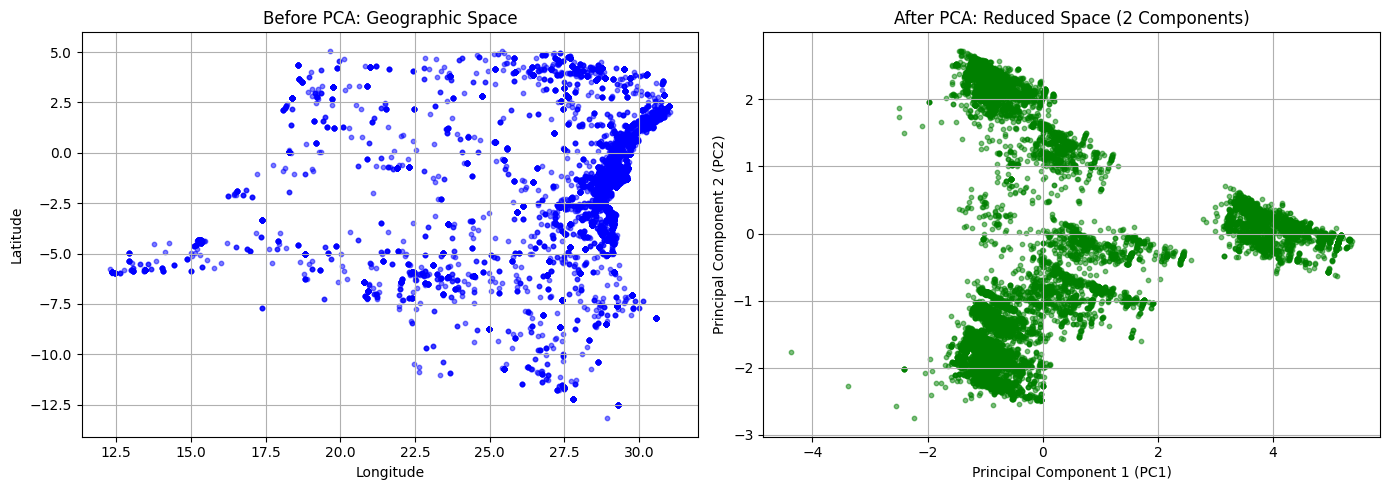

In [29]:
import matplotlib.pyplot as plt

# Step 8: Visualize Before and After PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot original data
axes[0].scatter(X_raw[:, 2], X_raw[:, 1], alpha=0.5, color='blue', s=10)
axes[0].set_title('Before PCA: Geographic Space')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(True)

# Plot reduced data after PCA
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5, color='green', s=10)
axes[1].set_title('After PCA: Reduced Space (2 Components)')
axes[1].set_xlabel('Principal Component 1 (PC1)')
axes[1].set_ylabel('Principal Component 2 (PC2)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

1. Interpret the Visual you just created of the before and after PCA

The left plot maps raw spatial coordinates, accurately displaying physical conflict clusters and density across the DRC. The right plot shows that same data mathematically compressed into two abstract axes of maximum variance (PC1 and PC2), the same number of points is preserved, and the broad clustering visible on the left survives, just rotated onto axes chosen for spread rather than geography.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

We let the algorithm dynamically select components until it reached an 80% variance threshold. This ensures we keep the most important mathematical information intact. The main tradeoff here is balancing aggressive data compression versus maintaining absolute exactness. By stopping at 80%, we intentionally throw away 20% of the minor, subtle details. We do this to make the model computationally faster and easier to visualize.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

When we shrink the data, the math heavily blends all of our original columns together. This creates a generalized summary instead of isolated data points. Because of this blending, we can no longer see specific, individual facts. We lose the exact number of "fatalities" or the specific "year" a conflict happened. We trade away those exact, real-world numbers just to get a broader big-picture view of the data.
